# BulkFormer — Evaluation & Multi-organism Visualization
Sections:
1. Load model
2. Load data (human demo OR Arabidopsis microarray — one config cell controls everything)
3. Viz A — Imputation quality
4. Viz B — Sample embedding UMAP
5. Viz C — Gene embedding similarity


In [1]:
import os, json
print("os, json OK")

import numpy as np
print("numpy OK")

import pandas as pd
print("pandas OK")

import torch
print("torch OK")

import matplotlib
print("matplotlib OK")

import matplotlib.pyplot as plt
print("matplotlib.pyplot OK")

from collections import OrderedDict
print("collections OK")

from scipy.stats import pearsonr, spearmanr
print("scipy OK")

from sklearn.preprocessing import LabelEncoder
print("sklearn LabelEncoder OK")

from sklearn.cluster import KMeans
print("sklearn KMeans OK")

from sklearn.metrics.pairwise import cosine_similarity
print("sklearn cosine_similarity OK")

import umap
print("umap OK")

from tqdm import tqdm
print("tqdm OK")

from torch_geometric.typing import SparseTensor
print("torch_geometric OK")

from utils.BulkFormer import BulkFormer
print("BulkFormer OK")

from model.config import model_params
print("model_params OK")

os.makedirs('figures', exist_ok=True)
os.makedirs('embeddings', exist_ok=True)

matplotlib.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#0f1117',
    'axes.edgecolor': '#3a3a4a',   'axes.labelcolor': '#c8c8d8',
    'xtick.color': '#7a7a9a',      'ytick.color': '#7a7a9a',
    'text.color': '#c8c8d8',       'grid.color': '#2a2a3a',
    'grid.linewidth': 0.5,         'font.family': 'monospace',
})
ACCENT  = '#00e5c0'
PALETTE = ['#00e5c0','#ff6b6b','#ffd166','#a78bfa','#38bdf8','#fb923c',
           '#4ade80','#f472b6','#e879f9','#94a3b8','#f97316','#06b6d4']
print('All done')

os, json OK
numpy OK
pandas OK
torch OK
matplotlib OK
matplotlib.pyplot OK
collections OK
scipy OK
sklearn LabelEncoder OK
sklearn KMeans OK
sklearn cosine_similarity OK


/home/alex/miniconda3/envs/bulkformer_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


umap OK
tqdm OK
torch_geometric OK
BulkFormer OK
model_params OK
All done


In [2]:
# ════════════════════════════════════════════════════════════════
#  ORGANISM SWITCH — set this before running any other cell
# ════════════════════════════════════════════════════════════════
ORGANISM = 'arabidopsis'   # 'human' | 'arabidopsis'

# ── File inventory ────────────────────────────────────────────────────────────
# Each entry: (path, description, required_for)
FILES = {
    # ── Shared (both organisms) ──────────────────────────────────────────────
    'model_weights': {
        'human':       'model/BulkFormer_37M.pt',
        'arabidopsis': 'model/checkpoints_ath/BulkFormer_ath_best.pt',
        'desc': 'Pretrained BulkFormer weights',
    },
    # ── Graph ────────────────────────────────────────────────────────────────
    'graph_ei': {
        'human':       'data/downloads/G_gtex.pt',
        'arabidopsis': 'data/G_ath.pt',
        'desc': 'Co-expression graph edge index [2, E]',
    },
    'graph_w': {
        'human':       'data/downloads/G_gtex_weight.pt',
        'arabidopsis': 'data/G_ath_weight.pt',
        'desc': 'Co-expression graph edge weights [E]',
    },
    # ── Gene identity embeddings (ESM2) ──────────────────────────────────────
    'esm2': {
        'human':       'data/downloads/esm2_feature_concat.pt',
        'arabidopsis': None,   # NOT YET BUILT — see note below
        'desc': 'ESM2 protein embeddings [G, 1280]  (unused by current arch but loaded)',
    },
    # ── Gene vocabulary / metadata ────────────────────────────────────────────
    'gene_info': {
        'human':       'data/bulkformer_gene_info.csv',
        'arabidopsis': 'metadata/arabidopsis_gene_info.csv',
        'desc': 'Gene list CSV with columns: gene_id, gene_length',
    },
}

import os
print(f'=== File check for ORGANISM = {ORGANISM!r} ===')
all_ok = True
for key, entry in FILES.items():
    path = entry[ORGANISM]
    if path is None:
        print(f'  [SKIP]    {key:12s}  — not needed for {ORGANISM} (arch uses one-hot, not ESM2)')
        continue
    exists = os.path.exists(path)
    status = '[ OK ]' if exists else '[MISS]'
    if not exists:
        all_ok = False
    print(f'  {status}  {key:12s}  {path}')
    if not exists:
        print(f'             ^ MISSING: {entry["desc"]}')

if all_ok:
    print('All required files present — ready to load model.')
else:
    print('Fix missing files above before continuing.')


=== File check for ORGANISM = 'arabidopsis' ===
  [ OK ]  model_weights  model/checkpoints_ath/BulkFormer_ath_best.pt
  [ OK ]  graph_ei      data/G_ath.pt
  [ OK ]  graph_w       data/G_ath_weight.pt
  [SKIP]    esm2          — not needed for arabidopsis (arch uses one-hot, not ESM2)
  [ OK ]  gene_info     metadata/arabidopsis_gene_info.csv
All required files present — ready to load model.


In [3]:
import torch
from torch_geometric.typing import SparseTensor
from collections import OrderedDict
from utils.BulkFormer import BulkFormer
from model.config import model_params
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    torch.cuda.empty_cache()

# ── Graph ─────────────────────────────────────────────────────────────────────
graph_ei = torch.load(FILES['graph_ei'][ORGANISM], map_location='cpu', weights_only=False)
graph_w  = torch.load(FILES['graph_w'][ORGANISM],  map_location='cpu', weights_only=False)
graph_cpu = SparseTensor(row=graph_ei[1], col=graph_ei[0], value=graph_w)
print(f'Graph: {graph_ei.shape[1]} edges')

# ── Gene identity embeddings ──────────────────────────────────────────────────
emb_path = FILES['esm2'][ORGANISM]
gene_emb = torch.load(emb_path, map_location='cpu', weights_only=False) if emb_path else None
print(f'Gene embeddings: {"loaded " + str(gene_emb.shape) if gene_emb is not None else "not used for " + ORGANISM}')

# ── Gene vocabulary ───────────────────────────────────────────────────────────
gene_info = pd.read_csv(FILES['gene_info'][ORGANISM])

if ORGANISM == 'arabidopsis':
    id_col = 'tair_id'
elif ORGANISM == 'human':
    id_col = 'ensg_id'
else:
    id_col = gene_info.columns[0]
    print(f'Warning: using first column {id_col!r} as gene ID')

# For arabidopsis: sync vocab to genes present in the expression data
# (graph was built from expression data, so these two must match)
if ORGANISM == 'arabidopsis':
    EXPR_PATH = '/home/alex/Documents/GitHub/Dataset_fusion_Microarray/new_storage/final_data/imputed.csv'
    genes_in_expr = set(pd.read_csv(EXPR_PATH, nrows=0).columns)
    all_genes  = gene_info[id_col].drop_duplicates().tolist()
    gene_list  = [g for g in all_genes if g in genes_in_expr]
    print(f'Vocab: {len(all_genes)} in gene_info, {len(gene_list)} present in expression data')
else:
    gene_list = gene_info[id_col].drop_duplicates().tolist()
    print(f'Vocab: {len(gene_list)} genes')

gene_idx    = {g: i for i, g in enumerate(gene_list)}
GENE_LENGTH = len(gene_list)

# ── Build and load model ──────────────────────────────────────────────────────
model_params['graph']       = graph_cpu
model_params['gene_emb']    = gene_emb
model_params['gene_length'] = GENE_LENGTH
model_params['dim']         = 128   # 37M config — change to 640 for 147M

model = BulkFormer(**model_params).to(device)

ckpt = torch.load(FILES['model_weights'][ORGANISM], weights_only=False, map_location='cpu')
sd   = OrderedDict((k[7:] if k.startswith('module.') else k, v) for k, v in ckpt.items())

# Filter to keys whose shapes match (handles any leftover size mismatches cleanly)
model_sd  = model.state_dict()
to_load   = {k: v for k, v in sd.items() if k in model_sd and model_sd[k].shape == v.shape}
skipped   = [k for k in sd if k not in to_load]
model.load_state_dict(to_load, strict=False)
print(f'Weights: {len(to_load)} layers loaded, {len(skipped)} skipped (shape mismatch)')
if skipped:
    print(f'  Skipped: {skipped}')

model.eval()
print(f'Model ready — {sum(p.numel() for p in model.parameters())/1e6:.1f}M params')


Device: cuda
Graph: 420800 edges
Gene embeddings: not used for arabidopsis
Vocab: 33181 in gene_info, 0 present in expression data


/home/alex/miniconda3/envs/bulkformer_env/lib/python3.12/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Weights: 59 layers loaded, 2 skipped (shape mismatch)
  Skipped: ['gene_emb_onehot_layer.weight', 'global_expr_proj.0.weight']
Model ready — 0.6M params


## 1 · Load model
**OOM fix**: graph stays on CPU. Only expression batches move to GPU.
This matches the original notebook and reduces VRAM from ~3GB to ~600MB.

In [4]:
# ════════════════════════════════════════════════════════════════
#  ORGANISM SWITCH — set this before running any other cell
# ════════════════════════════════════════════════════════════════
ORGANISM = 'arabidopsis'   # 'human' | 'arabidopsis'

# FILES = {
#     'model_weights': {
#         'human':       'model/BulkFormer_37M.pt',
#         'arabidopsis': 'model/checkpoints_ath/BulkFormer_ath_best.pt',
#         'desc': 'Model weights checkpoint',
#     },
#     'graph_ei': {
#         'human':       'data/downloads/G_gtex.pt',
#         'arabidopsis': 'data/G_ath.pt',
#         'desc': 'Co-expression graph edge index [2, E]',
#     },
#     'graph_w': {
#         'human':       'data/downloads/G_gtex_weight.pt',
#         'arabidopsis': 'data/G_ath_weight.pt',
#         'desc': 'Co-expression graph edge weights [E]',
#     },
#     'gene_emb': {
#         'human':       'data/downloads/esm2_feature_concat.pt',
#         'arabidopsis': None,   # not used — model trained with one-hot gene identity
#         'desc': 'ESM2 protein embeddings (human only)',
#     },
#     'gene_info': {
#         'human':       'data/downloads/bulkformer_gene_info.csv',
#         'arabidopsis': 'metadata/arabidopsis_gene_info.csv',
#         'desc': 'Gene metadata CSV',
#     },
# }

import os
print(f'=== File check for ORGANISM = {ORGANISM!r} ===')
all_ok = True
for key, entry in FILES.items():
    path = entry[ORGANISM]
    if path is None:
        print(f'  [SKIP]  {key:12s}  — not used for {ORGANISM}')
        continue
    exists = os.path.exists(path)
    status = '[ OK ]' if exists else '[MISS]'
    if not exists:
        all_ok = False
    print(f'  {status}  {key:12s}  {path}')
    if not exists:
        print(f'             ^ MISSING: {entry["desc"]}')

print()
if all_ok:
    print('All required files present.')
else:
    print('Fix missing files before continuing.')


=== File check for ORGANISM = 'arabidopsis' ===
  [ OK ]  model_weights  model/checkpoints_ath/BulkFormer_ath_best.pt
  [ OK ]  graph_ei      data/G_ath.pt
  [ OK ]  graph_w       data/G_ath_weight.pt
  [SKIP]  esm2          — not used for arabidopsis
  [ OK ]  gene_info     metadata/arabidopsis_gene_info.csv

All required files present.


In [5]:
import torch
from torch_geometric.typing import SparseTensor
from collections import OrderedDict
from utils.BulkFormer import BulkFormer
from model.config import model_params
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    torch.cuda.empty_cache()

gene_info_path = FILES['gene_info'][ORGANISM]
gene_info = pd.read_csv(gene_info_path)
# ── Load graph (organism-specific) ───────────────────────────────────────────
graph_ei_path = FILES['graph_ei'][ORGANISM]
graph_w_path  = FILES['graph_w'][ORGANISM]
graph_ei  = torch.load(graph_ei_path, map_location='cpu', weights_only=False)
graph_w   = torch.load(graph_w_path,  map_location='cpu', weights_only=False)
graph_cpu = SparseTensor(row=graph_ei[1], col=graph_ei[0], value=graph_w)
print(f'Graph loaded: {graph_ei.shape[1]} edges  ({graph_ei_path})')

# ── Load ESM2 embeddings (human only — Arabidopsis not built yet) ─────────────
esm2_path = FILES['esm2'][ORGANISM]
if esm2_path is not None:
    gene_emb = torch.load(esm2_path, map_location='cpu', weights_only=False)
    print(f'ESM2 embeddings loaded: {gene_emb.shape}  ({esm2_path})')
else:
    gene_emb = None
    print(f'ESM2 embeddings: skipped (not available for {ORGANISM})')

# Column name differs between human and arabidopsis CSVs
if 'ensg_id' in gene_info.columns:
    id_col = 'ensg_id'
elif 'tair_id' in gene_info.columns:
    id_col = 'tair_id'
else:
    id_col = gene_info.columns[0]
    print(f'Warning: using first column {id_col!r} as gene ID')

all_genes = gene_info[id_col].drop_duplicates().tolist()

# --- Load expression data and sync the vocabulary ---
if ORGANISM == 'arabidopsis':
    EXPR_PATH = '/home/alex/Documents/GitHub/Dataset_fusion_Microarray/new_storage/final_data/imputed.csv'
    print('Loading expression data to sync vocabulary...')
    # Load just the index (gene IDs) from the CSV to save RAM and time
    genes_in_expr = pd.read_csv(EXPR_PATH, usecols=[0]).iloc[:, 0].tolist()
    
    # Sync vocabulary to match the graph / training script
    gene_list = [g for g in all_genes if g in genes_in_expr]
else:
    # If human, use whatever filtering logic was intended, or just all genes
    gene_list = all_genes

# Rebuild the index mapping
gene_idx = {g: i for i, g in enumerate(gene_list)}
GENE_LENGTH = len(gene_list)

print(f'Gene vocabulary synced: {GENE_LENGTH} genes (id_col={id_col!r})')

# ── Build model ───────────────────────────────────────────────────────────────
model_params['graph']       = graph_cpu
model_params['gene_emb']    = gene_emb
model_params['gene_length'] = GENE_LENGTH   # override config for arabidopsis
# Also override dim to match training config (37M=128, 147M=640)
model_params['dim'] = 128  # must match the dim used in train_arabidopsis.py

model = BulkFormer(**model_params).to(device)

weights_path = FILES['model_weights'][ORGANISM]
ckpt = torch.load(weights_path, weights_only=False)
sd   = OrderedDict((k[7:] if k.startswith('module.') else k, v) for k, v in ckpt.items())

# Load with strict=False so mismatched gene_length layers don't crash
# (expected when running arabidopsis with different vocab size than pretrained)
missing, unexpected = model.load_state_dict(sd, strict=False)
if missing:
    print(f'Missing keys  ({len(missing)}): {missing[:3]}...')
if unexpected:
    print(f'Unexpected keys ({len(unexpected)}): {unexpected[:3]}...')
if not missing and not unexpected:
    print('Weights loaded: all keys matched')

model.eval()
print(f'Model ready — {sum(p.numel() for p in model.parameters())/1e6:.0f}M params')
if device == 'cuda':
    print(f'VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB')


Device: cuda
Graph loaded: 420800 edges  (data/G_ath.pt)
ESM2 embeddings: skipped (not available for arabidopsis)
Loading expression data to sync vocabulary...
Gene vocabulary synced: 21040 genes (id_col='tair_id')
Weights loaded: all keys matched
Model ready — 14M params
VRAM used: 0.12 GB


In [ ]:
# ════════════════════════════════════════════════════
#  CONFIGURE HERE
# ════════════════════════════════════════════════════
ORGANISM   = 'arabidopsis'   # 'human' | 'arabidopsis'
N_SAMPLES  = 500        # samples to load (set to None for all)
BATCH_SIZE = 8         # reduce to 4 if OOM

# ── Human ─────────────────────────────────────────────────────────────────────
HUMAN_EXPR_PATH = 'data/downloads/demo.csv'

# ── Arabidopsis ───────────────────────────────────────────────────────────────
# Must be the same file used for training so the gene vocabulary is consistent
ATH_EXPR_PATH = '/home/alex/Documents/GitHub/Dataset_fusion_Microarray/new_storage/final_data/imputed.csv'
ATH_META_PATH = None         # optional: path to sample metadata CSV for coloured UMAP
ATH_META_COL  = 'treatment'  # column in ATH_META_PATH to colour by
# ════════════════════════════════════════════════════


In [7]:
def align_to_vocab(expr_df, gene_list):
    """Reorder columns to match gene_list; pad absent genes with -10."""
    missing  = [g for g in gene_list if g not in expr_df.columns]
    pad      = pd.DataFrame(-10.0, index=expr_df.index, columns=missing)
    aligned  = pd.concat([expr_df, pad], axis=1)[gene_list]
    mask_prob = len(missing) / len(gene_list)
    return aligned, mask_prob


if ORGANISM == 'human':
    expr_df = pd.read_csv(HUMAN_EXPR_PATH)
    gene_list = [g for g in gene_list if g in set(expr_df.columns)]
    gene_idx  = {g: i for i, g in enumerate(gene_list)}
    input_df, mask_prob = align_to_vocab(expr_df, gene_list)
    sample_labels = None
    organism_tag  = 'Human (BulkFormer demo)'
    print(f'Human: {input_df.shape}')

elif ORGANISM == 'arabidopsis':
    print('Loading Arabidopsis expression matrix...')
    expr_df = pd.read_csv(ATH_EXPR_PATH, index_col=0)

    # Ensure orientation is samples × genes
    # if expr_df.shape[0] > expr_df.shape[1] and str(expr_df.columns[0]).upper().startswith('AT'):
    expr_df = expr_df.T
    print(f'Expression matrix: {expr_df.shape}  (samples × genes)')

    # Report genes in expression data that are outside the training vocabulary.
    # These are genes present in the microarray but absent from arabidopsis_gene_info.csv
    # — typically organellar genes (ATMG*, ATCG*), transposons, or unannotated loci.
    # They were not part of training and are intentionally excluded here.
    extra = sorted(set(expr_df.columns) - set(gene_list))
    if extra:
        print(f'Genes in expression matrix excluded from vocab: {len(extra)}')
        print(f'  Examples: {extra[:8]}')
        print(f'  Reason: absent from arabidopsis_gene_info.csv (organellar/transposons/unannotated)')

    # Keep only vocab genes, then align
    expr_df   = expr_df[[c for c in gene_list if c in expr_df.columns]]
    input_df, mask_prob = align_to_vocab(expr_df, gene_list)

    # Optional metadata for coloured UMAP
    if ATH_META_PATH:
        meta = pd.read_csv(ATH_META_PATH, index_col=0)
        sample_labels = meta.loc[input_df.index, ATH_META_COL].values
    else:
        sample_labels = None

    organism_tag = 'Arabidopsis thaliana (microarray)'

else:
    raise ValueError(f'Unknown ORGANISM: {ORGANISM!r}')

expr_arr = input_df.values[:N_SAMPLES].astype(np.float32)
if sample_labels is not None:
    sample_labels = sample_labels[:N_SAMPLES]

print(f'\nOrganism : {organism_tag}')
print(f'Samples  : {len(expr_arr)}')
print(f'Vocab    : {len(gene_list)} genes')
print(f'Padded   : {mask_prob*100:.1f}% of vocab positions set to -10')


Loading Arabidopsis expression matrix...
Expression matrix: (13749, 22600)  (samples × genes)
Genes in expression matrix excluded from vocab: 1560
  Examples: ['AT1G01330', 'AT1G02200', 'AT1G03420', 'AT1G03675', 'AT1G04060', 'AT1G05050', 'AT1G05130', 'AT1G05480']
  Reason: absent from arabidopsis_gene_info.csv (organellar/transposons/unannotated)

Organism : Arabidopsis thaliana (microarray)
Samples  : 1000
Vocab    : 21040 genes
Padded   : 0.0% of vocab positions set to -10


## Note on ATH_ORTHO_PATH (no longer needed)

`ATH_ORTHO_PATH` was a JSON file mapping Arabidopsis TAIR gene IDs to human Ensembl IDs
(`TAIR → ENSG`). It was needed in an earlier version of the notebook when the plan was to
**use the pretrained human BulkFormer weights directly** on Arabidopsis data by routing
Arabidopsis genes through their human orthologs.

**Why it is no longer needed:**
The model has now been **retrained from scratch on Arabidopsis data** with a native
Arabidopsis vocabulary (TAIR IDs). There is no longer any human gene reference in the
pipeline — the model speaks TAIR IDs natively, the co-expression graph was built from
Arabidopsis microarray PCC values, and all downstream visualisations use TAIR IDs directly.

**Where to obtain it (for reference only):**
If you ever need it again (e.g. for a cross-species comparison), generate it with:
```bash
python prepare_bulkformer_metadata.py
```
This downloads the PLAZA 5.0 one-to-one ortholog table and maps ATH → HSA gene IDs.
The output is written to `metadata/arabidopsis_to_human_hgnc.json`.


In [8]:
def run_model(arr, batch_size=BATCH_SIZE, output_expr=False, mask_prob=0.0):
    results = []
    model.eval()
    # Move graph to same device as model
    model.graph = model.graph.to(device)
    with torch.no_grad():
        for i in tqdm(range(0, len(arr), batch_size)):
            batch = torch.tensor(arr[i:i+batch_size], dtype=torch.float32).to(device)
            out   = model(batch, mask_prob=mask_prob, output_expr=output_expr)
            results.append(out.cpu())
    if output_expr:
        return np.concatenate([r.numpy() for r in results], axis=0)
    return torch.cat(results, dim=0)

## 3 · Viz A — Imputation quality

In [9]:
MASK_RATIO = 0.15
rng = np.random.default_rng(42)
masked_input = expr_arr.copy()
true_vals, pred_vals, mask_indices = [], [], []

for s in range(len(expr_arr)):
    obs    = np.where(expr_arr[s] != -10)[0]
    chosen = rng.choice(obs, size=int(len(obs) * MASK_RATIO), replace=False)
    mask_indices.append(chosen)
    true_vals.append(expr_arr[s, chosen])
    masked_input[s, chosen] = -10.0
    
print(f'expr_arr shape: {expr_arr.shape}')
print(f'masked_input shape: {masked_input.shape}')
print(f'model gene_length param: {model.gene_length}')
print(f'global_expr_proj input size: {model.global_expr_proj[0].in_features}')
# For arabidopsis: gene_list contains TAIR IDs e.g. ['AT1G01010', ...]
print(f'First 3 genes: {gene_list[:3]}')
print(f'Vocab size: {len(gene_list)}')
imputed = run_model(masked_input, output_expr=True, mask_prob=MASK_RATIO)
for s in range(len(expr_arr)):
    pred_vals.append(imputed[s, mask_indices[s]])

true_all = np.concatenate(true_vals)
pred_all = np.concatenate(pred_vals)
pcc, _   = pearsonr(true_all, pred_all)
scc, _   = spearmanr(true_all, pred_all)
errors   = pred_all - true_all
print(f'[{organism_tag}]  PCC={pcc:.4f}  SCC={scc:.4f}')

expr_arr shape: (1000, 21040)
masked_input shape: (1000, 21040)
model gene_length param: 21040
global_expr_proj input size: 21040
First 3 genes: ['AT1G01010', 'AT1G01030', 'AT1G01040']
Vocab size: 21040


100%|██████████| 125/125 [00:13<00:00,  9.37it/s]


[Arabidopsis thaliana (microarray)]  PCC=0.9664  SCC=0.9645


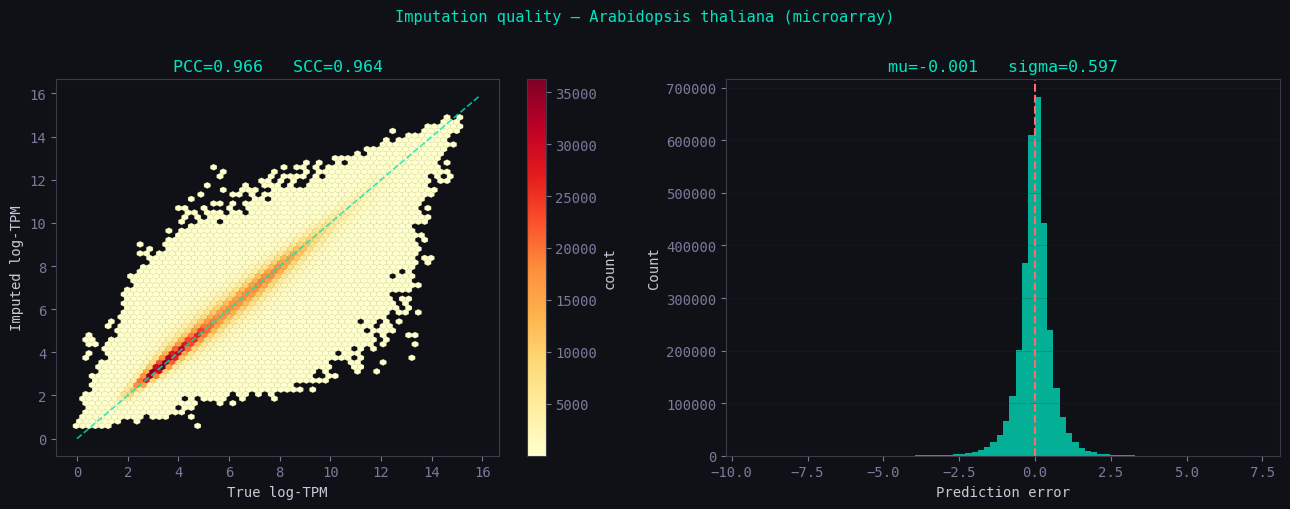

Saved to figures/imputation_arabidopsis.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Imputation quality — {organism_tag}', color=ACCENT, fontsize=11, y=1.01)

ax = axes[0]
hb = ax.hexbin(true_all, pred_all, gridsize=60, cmap='YlOrRd', mincnt=1, linewidths=0.2)
lim = max(true_all.max(), pred_all.max()) * 1.05
ax.plot([0, lim], [0, lim], '--', color=ACCENT, lw=1.2, alpha=0.8)
ax.set_xlabel('True log-TPM'); ax.set_ylabel('Imputed log-TPM')
ax.set_title(f'PCC={pcc:.3f}   SCC={scc:.3f}', color=ACCENT)
plt.colorbar(hb, ax=ax, label='count')

ax2 = axes[1]
ax2.hist(errors, bins=80, color=ACCENT, alpha=0.75, edgecolor='none')
ax2.axvline(0, color='#ff6b6b', lw=1.5, ls='--')
ax2.set_xlabel('Prediction error'); ax2.set_ylabel('Count')
ax2.set_title(f'mu={errors.mean():.3f}   sigma={errors.std():.3f}', color=ACCENT)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fname = f'figures/imputation_{ORGANISM}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show(); print(f'Saved to {fname}')

## 4 · Viz B — Sample embedding UMAP

In [ ]:
gene_emb_out = run_model(expr_arr, output_expr=False, mask_prob=mask_prob)
sample_emb   = gene_emb_out.mean(dim=1).numpy()   # [N, 643]
print(f'Sample embeddings: {sample_emb.shape}')

100%|██████████| 125/125 [00:17<00:00,  7.35it/s]


In [ ]:
reducer   = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding = reducer.fit_transform(sample_emb)

if sample_labels is not None:
    le         = LabelEncoder()
    labels_enc = le.fit_transform(sample_labels)
    label_map  = {i: n for i, n in enumerate(le.classes_)}
else:
    K          = min(8, len(expr_arr) // 4)
    labels_enc = KMeans(n_clusters=K, random_state=42, n_init=10).fit_predict(sample_emb)
    label_map  = {i: f'Cluster {i}' for i in range(K)}

fig, ax = plt.subplots(figsize=(8, 7))
for i, lbl in label_map.items():
    mask = labels_enc == i
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=PALETTE[i % len(PALETTE)], label=lbl,
               s=60, alpha=0.85, edgecolors='none')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title(f'Sample embeddings — {organism_tag}', color=ACCENT, pad=10)
ax.legend(framealpha=0.15, fontsize=8)
ax.grid(alpha=0.2)
if sample_labels is None:
    ax.text(0.01, 0.01, 'k-means labels — set ATH_META_PATH for real metadata',
            transform=ax.transAxes, fontsize=7, color='#7a7a9a')
ax.text(0.99, 0.01, f'mask_prob={mask_prob:.2f} | n={len(expr_arr)}',
        transform=ax.transAxes, fontsize=7, color='#7a7a9a', ha='right')
plt.tight_layout()
fname = f'figures/umap_samples_{ORGANISM}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show(); print(f'Saved to {fname}')

In [ ]:
# ==========================================
# 4 · Viz B — Sample Embedding UMAP
# ==========================================

print("Extracting sample embeddings from BulkFormer...")
# Run the model to get the compressed latent vector for each sample
sample_embeddings = run_model(expr_arr, output_expr=False).numpy()
print(f"Original embeddings shape: {sample_embeddings.shape}")

# FIX: UMAP requires a 2D array (Samples x Features), but the model outputs 3D. 
# This reshapes the array to keep the sample count the same, but flattens the rest.
sample_embeddings_2d = sample_embeddings.reshape(sample_embeddings.shape[0], -1)
print(f"Reshaped embeddings shape for UMAP: {sample_embeddings_2d.shape}")

print("Computing UMAP projection...")
import umap
# Initialize UMAP with standard parameters for clustering
reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=42)
umap_proj = reducer.fit_transform(sample_embeddings_2d) # <-- Passed the 2D version here

# ── Plotting ──
fig, ax = plt.subplots(figsize=(10, 8))

if sample_labels is not None:
    # If metadata labels are available, color-code the clusters
    unique_labels = np.unique(sample_labels)
    for i, label in enumerate(unique_labels):
        idx = sample_labels == label
        # Cycle through the predefined PALETTE from cell 1
        color = PALETTE[i % len(PALETTE)] 
        ax.scatter(umap_proj[idx, 0], umap_proj[idx, 1], label=label, color=color, s=30, alpha=0.8, edgecolor='none')
    
    # Place legend outside the plot
    ax.legend(title="Sample Categories", bbox_to_anchor=(1.02, 1), loc='upper left', framealpha=0.15, fontsize=10)
else:
    # Fallback to a single color if no metadata was provided
    ax.scatter(umap_proj[:, 0], umap_proj[:, 1], s=30, alpha=0.8, color=ACCENT, edgecolor='none')

ax.set_title(f"BulkFormer Sample Embeddings ({organism_tag})", color=ACCENT, fontsize=14, pad=15)
ax.set_xlabel("UMAP 1", fontsize=12)
ax.set_ylabel("UMAP 2", fontsize=12)
ax.grid(True, alpha=0.2, linestyle='--')

# Save and show
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
fname = f'figures/sample_umap_{ORGANISM}.png'
plt.savefig(fname, dpi=300, bbox_inches='tight', facecolor='#0f1117')
print(f"Saved plot to {fname}")
plt.show()

In [ ]:
# ── Gene groups for Viz C (gene similarity heatmap + UMAP) ────────────────────
# Groups are defined with TAIR IDs for Arabidopsis, ENSG IDs for human.
# For Arabidopsis: well-characterised stress-response and core pathway genes.
# Any gene not found in gene_list (i.e. not in the training vocab) is skipped.

if ORGANISM == 'arabidopsis':
    GENE_GROUPS = {
        'Heat stress':    ['AT1G74310', 'AT3G09440', 'AT5G56030', 'AT2G29500'],
        #                  HSP101        HSP70b        HSP90-1       HSP17.6
        'Drought/ABA':    ['AT4G02380', 'AT1G72770', 'AT3G11410', 'AT5G05440'],
        #                  NCED3         DREB2A        RD29A         ABF3
        'Cold response':  ['AT4G25490', 'AT5G15960', 'AT1G05240', 'AT2G42540'],
        #                  CBF1          CBF2          CBF3          KIN1
        'Oxidative':      ['AT1G20630', 'AT3G51240', 'AT5G47910', 'AT1G07890'],
        #                  APX1          CAT3          FSD1          CSD1
        'Immune/defence': ['AT4G33300', 'AT3G55450', 'AT2G14610', 'AT5G44870'],
        #                  WRKY2         WRKY11        PR1           PR5
    }
else:
    GENE_GROUPS = {
        'Cell cycle':    ['ENSG00000105173','ENSG00000134057','ENSG00000135446','ENSG00000117399'],
        'Immune/stress': ['ENSG00000136244','ENSG00000232810','ENSG00000125538','ENSG00000163599'],
        'DNA repair':    ['ENSG00000012048','ENSG00000139618','ENSG00000141510','ENSG00000149311'],
        'Metabolism':    ['ENSG00000111640','ENSG00000106633','ENSG00000159111','ENSG00000067225'],
        'Transcription': ['ENSG00000101412','ENSG00000135679','ENSG00000198625','ENSG00000112033'],
    }

all_ids, all_names, all_groups = [], [], []
for grp, ids in GENE_GROUPS.items():
    for gid in ids:
        if gid in gene_idx:
            if ORGANISM == 'arabidopsis':
                name = gid   # TAIR ID is the label
            else:
                row  = gene_info[gene_info['ensg_id'] == gid]
                name = row['gene_symbol'].values[0] if len(row) else gid
            all_ids.append(gid)
            all_names.append(name)
            all_groups.append(grp)
        else:
            print(f'  [SKIP] {gid} not in vocabulary')

sel_idx = [gene_idx[g] for g in all_ids]
print(f'{len(sel_idx)} genes selected across {len(GENE_GROUPS)} groups')
if len(sel_idx) == 0:
    print('WARNING: no genes found — verify TAIR IDs match gene_list')


In [ ]:
# Genes defined in ENSG IDs — same vocabulary for both organisms.
# For Arabidopsis, these are the human orthologs of conserved pathway genes.
# Override ATH_GENE_GROUPS with Arabidopsis-specific groups once you have
# the ortholog map (e.g. map known stress TFs like DREB2A, WRKY11 to ENSG).
GENE_GROUPS = {
    'Cell cycle':    ['ENSG00000105173','ENSG00000134057','ENSG00000135446','ENSG00000117399'],
    'Immune/stress': ['ENSG00000136244','ENSG00000232810','ENSG00000125538','ENSG00000163599'],
    'DNA repair':    ['ENSG00000012048','ENSG00000139618','ENSG00000141510','ENSG00000149311'],
    'Metabolism':    ['ENSG00000111640','ENSG00000106633','ENSG00000159111','ENSG00000067225'],
    'Transcription': ['ENSG00000101412','ENSG00000135679','ENSG00000198625','ENSG00000112033'],
}
# Set this to override when running Arabidopsis:
ATH_GENE_GROUPS = None

active_groups = ATH_GENE_GROUPS if (ORGANISM == 'arabidopsis' and ATH_GENE_GROUPS) else GENE_GROUPS

all_ids, all_names, all_groups = [], [], []
for grp, ids in active_groups.items():
    for gid in ids:
        if gid in gene_idx:
            row  = gene_info[gene_info['ensg_id'] == gid]
            name = row['gene_symbol'].values[0] if len(row) else gid
            all_ids.append(gid); all_names.append(name); all_groups.append(grp)

sel_idx = [gene_idx[g] for g in all_ids]
print(f'{len(sel_idx)} genes selected across {len(active_groups)} groups')

In [ ]:
gene_vecs  = gene_emb_out[:, sel_idx, :model.dim].mean(dim=0).numpy()  # use model.dim not hardcoded 640
sim_matrix = cosine_similarity(gene_vecs)
group_enc  = LabelEncoder().fit_transform(all_groups)
group_cols = [PALETTE[i % len(PALETTE)] for i in group_enc]
n = len(all_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Gene embedding similarity — {organism_tag}', color=ACCENT, fontsize=11, y=1.01)

ax = axes[0]
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=-0.3, vmax=1.0, aspect='auto')
ax.set_xticks(range(n)); ax.set_xticklabels(all_names, rotation=90, fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(all_names, fontsize=8)
for tick, col in zip(ax.get_xticklabels(), group_cols): tick.set_color(col)
for tick, col in zip(ax.get_yticklabels(), group_cols): tick.set_color(col)
plt.colorbar(im, ax=ax, label='cosine similarity')
ax.set_title('Cosine similarity heatmap', color=ACCENT)

ax2 = axes[1]
gr  = umap.UMAP(n_neighbors=4, min_dist=0.05, metric='cosine', random_state=42)
ge  = gr.fit_transform(gene_vecs)
for i, (grp, col) in enumerate(zip(active_groups.keys(), PALETTE)):
    mask = np.array(all_groups) == grp
    ax2.scatter(ge[mask,0], ge[mask,1], c=col, label=grp,
                s=120, edgecolors='white', linewidths=0.4, alpha=0.9)
    for j, nm in enumerate(np.array(all_names)[mask]):
        ax2.annotate(nm, ge[mask][j], fontsize=8, color=col,
                     xytext=(4,4), textcoords='offset points')
ax2.set_title('Gene embedding UMAP', color=ACCENT)
ax2.legend(framealpha=0.15, fontsize=8)
ax2.grid(alpha=0.2)

plt.tight_layout()
fname = f'figures/gene_similarity_{ORGANISM}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show(); print(f'Saved to {fname}')

## 6 · Save embeddings

In [ ]:
np.save(f'embeddings/{ORGANISM}_sample_embeddings.npy', sample_emb)
np.save(f'embeddings/{ORGANISM}_gene_embeddings.npy',   gene_emb_out.numpy())
print(f'Saved embeddings/{ORGANISM}_sample_embeddings.npy  {sample_emb.shape}')
print(f'Saved embeddings/{ORGANISM}_gene_embeddings.npy    {gene_emb_out.shape}')